# Comparative analysis of machine learning models using EPANET datasets in water infrastructure

## Network file description and additional information ##

The Water Sensor Network 1 system is a hypothetical network created as part of a Battle of the Networks aimed to optimize water network design. The system has a total system demand of 1.3 million gallons per day (MGD) (~4921035 Liters per day), one reservoir, two pump stations, two tanks, and 23.3 miles of pipe. It is classified as transmission dense-loop by Hwang & Lansey (2017) and Hoagland et al. (2015).(Ostfeld, 2021)

The Water Sensor Network 1 system comes with four scenarions/patterns which dictate the analysis time and demand (to be more specific, the demand multiplier, which then deviates system demand). For the analysis scenario, 'PATTERN-0' is chosen, since it roughly resembles typical water demand of a network with ebbs and peaks in daily demand. PATTERN-0 spans over a time period of 96 hours. 

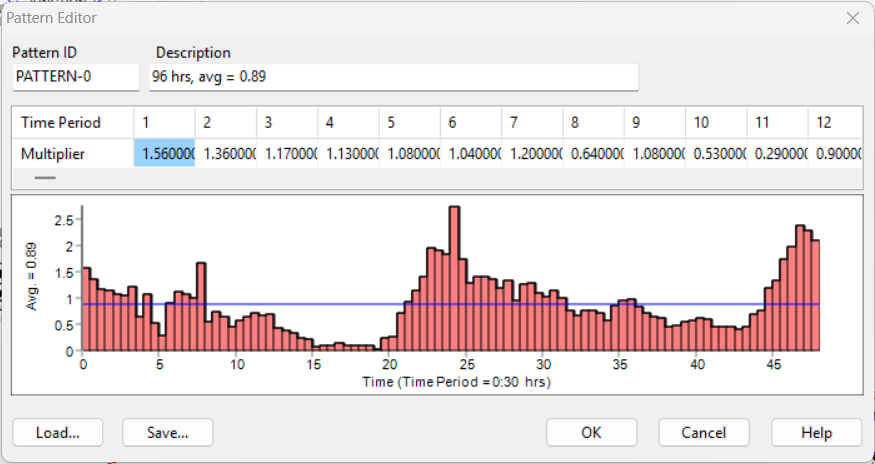

<sub>**Figure 2:** PATTERN-0 demand multiplier curve over 96 hours, showing daily cyclical water demand patterns.</sub>

## EPANET Anaylsis settings

EPANET has several settings that impact how an analysis of the water network. The Analysis Settings can be accessed via the data browser and are as follows:

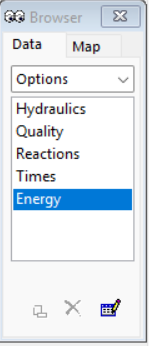

<sub>**Figure 3:** EPANET data browser interface for accessing analysis settings.</sub>

For this analysis, we will concetrate on the Hydraulics and Times options. Hydraulics options include options for flow units, headloss formula (energy loss due to pipe roughness), demand pattern and more. As we use a reference network, we will use the analysis options provided:

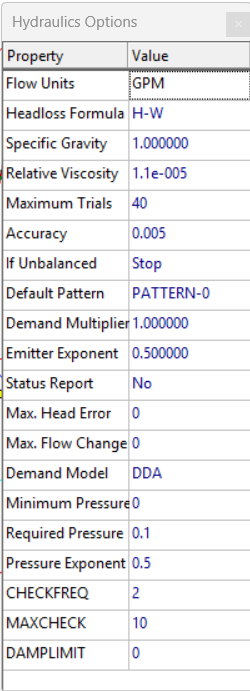 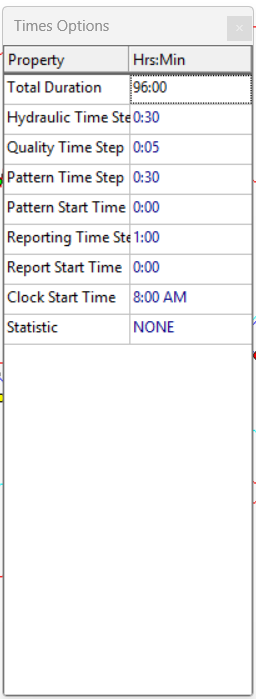

<sub>**Figure 4:** Hydraulics options (left) and Times options (right) configured for the network analysis.</sub>

## Data Analysis - Pressure Prediction using XGBoost algorithm

### 1. Automated Data Preprocessing

The EPANET report is parsed directly from the raw `.txt` output file using a regex-based parser that identifies node result sections by their time-stamped headers and extracts hydraulic variables (pressure, demand, head) for each junction at every time step. Page breaks, column headers, and separator lines are filtered out during parsing.

Node elevation, base demand, and demand multipliers are sourced from `NodeInfo.xlsx` and `Patterns.xlsx`, which were extracted from the EPANET input file.

### 2. Pandas Pre-Processing

### Import of Tables and selected Data formatting

In [12]:
# Import necessary libraries
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
from pygam import GAM
from interpret.glassbox import ExplainableBoostingRegressor

# ── Parse EPANET report: node results + link results in one pass ────────
RPT_FILE = Path('WSN1 - report.txt')
RE_NODE_HEADER = re.compile(r"Node Results at\s+(\d+):(\d+)\s+Hrs:", re.IGNORECASE)
RE_LINK_HEADER = re.compile(r"Link Results at\s+(\d+):(\d+)\s+Hrs:", re.IGNORECASE)
HEADERS = [(RE_NODE_HEADER, "node"),(RE_LINK_HEADER, "link"),]
node_rows, link_rows = [], []
NODE_PREFIXES = ("JUNCTION-", "RESERVOIR-", "TANK-")
LINK_PREFIXES = ("LINK-", "PUMP-", "VALVE-")
PREFIX_TO_TYPE = {
    "JUNCTION-": "Junction",
    "RESERVOIR-": "Reservoir",
    "TANK-":      "Tank",
    "LINK-":      "Link",
    "PUMP-":      "Pump",
    "VALVE-":     "Valve",
    }

current_time = 0.0
mode = ""
node_errors = link_errors = 0

with open(RPT_FILE) as f:
    for raw_line in f:
        line = raw_line.strip()
        if not line or line.startswith("Page "):
            continue
        
        for pattern, label in HEADERS:
            if m := pattern.search(line):
                current_time = int(m.group(1)) + int(m.group(2)) / 60.0
                mode = label
                continue

        parts = line.split()
        data_type = next((t for p, t in PREFIX_TO_TYPE.items() if line.startswith(p)), None)

        if mode == "node" and any(line.startswith(p) for p in NODE_PREFIXES) & (len(parts) >= 5):
            try:
                node_rows.append({
                    'Node-ID': parts[0],
                    'Node Type': data_type,
                    'Demand': float(parts[1]),
                    'Head': float(parts[2]),
                    'Pressure [psi]': float(parts[3]),
                    'hours': current_time,
                })
            except ValueError:
                node_errors += 1
        elif mode == "link" and any(line.startswith(p) for p in LINK_PREFIXES) & (len(parts) >= 5):
            try:
                link_rows.append({
                    'Link-ID': parts[0],
                    'Link Type': data_type,
                    'Flow [GPM]': float(parts[1]),
                    'Velocity [fps]': float(parts[2]),
                    'Headloss [ft/Kft]': float(parts[3]),
                    'Status': parts[4],
                    'hours': current_time,
                })
            except ValueError:
                link_errors += 1

JunctionPressures = pd.DataFrame(node_rows)
LinkResults = pd.DataFrame(link_rows)
print(f"Parsed {len(node_rows):,} node rows ({node_errors} parse errors)")
print(f"Parsed {len(link_rows):,} link rows ({link_errors} parse errors)")
print()
print(JunctionPressures.describe())
print(LinkResults.describe())


Parsed 743,169 node rows (0 parse errors)
Parsed 1,025,458 link rows (0 parse errors)

              Demand           Head  Pressure [psi]          hours
count  743169.000000  743169.000000   743169.000000  743169.000000
mean       -0.001473     817.963279      101.464618      48.000000
std       163.084380     147.441035       59.756351      27.717642
min     -3015.620000     424.590000        0.000000       0.000000
25%         0.000000     855.960000       85.170000      24.000000
50%         0.730000     857.740000      100.640000      48.000000
75%         3.740000     859.150000      104.340000      72.000000
max      2379.380000    1172.350000      507.980000      96.000000
         Flow [GPM]  Velocity [fps]  Headloss [ft/Kft]         hours
count  1.025458e+06    1.025458e+06       1.025458e+06  1.025458e+06
mean   2.322445e+01    1.864297e-01       3.608096e+00  4.800000e+01
std    3.806759e+02    5.393223e-01       3.742408e+01  2.771764e+01
min   -3.015620e+03    0.000000e+0

In [13]:
# ── Parse NodeInfo from WSN1.inp [JUNCTIONS] ────────────────────────────
INP_FILE = Path('WSN1.inp')
node_info_rows = []
in_junctions = False

with open(INP_FILE) as f:
    for line in f:
        stripped = line.strip()
        if stripped == "[JUNCTIONS]":
            in_junctions = True
            continue
        if in_junctions and stripped.startswith("["):
            break
        if not in_junctions or stripped.startswith(";") or not stripped:
            continue
        parts = stripped.split()
        if len(parts) >= 3:
            node_info_rows.append({
                'Node': parts[0],
                'Elev': float(parts[1]),
                'Base Demand [GPM]': float(parts[2]),
                'Pattern': parts[3] if len(parts) > 3 else '',
            })

NodeInfo = pd.DataFrame(node_info_rows)
print("Table 2: Node information data preview (first 5 rows)")
print(NodeInfo.head())
print()

JunctionPressures = pd.merge(JunctionPressures, NodeInfo, on='Node', how='left')
# ── Parse Patterns from WSN1.inp [PATTERNS] (PATTERN-0, 0.5-hr steps) ───
pattern_values = []
in_patterns = False

with open(INP_FILE, encoding="latin-1") as f:
    for line in f:
        stripped = line.strip()
        if stripped == "[PATTERNS]":
            in_patterns = True
            continue
        if in_patterns and stripped.startswith("["):
            break
        if not in_patterns or stripped.startswith(";") or not stripped:
            continue
        parts = stripped.split()
        if parts[0] == "PATTERN-0":
            pattern_values.extend(float(v) for v in parts[1:])

# Pattern timestep = 0.5 hr; extend over 96-hour simulation (pattern repeats)
PATTERN_STEP = 0.5
n = len(pattern_values)
full_hours, full_mults = [], []
h = 0.0
while h < 96:
    full_hours.append(round(h, 1))
    full_mults.append(pattern_values[int(round(h / PATTERN_STEP)) % n])
    h = round(h + PATTERN_STEP, 1)

Patterns = pd.DataFrame({'hours': full_hours, 'Demand Multiplier': full_mults})
print("Table 3: Demand patterns data preview (first 5 rows)")
print(Patterns.head())

# ── Merge NodeInfo into JunctionPressures; Patterns merged in Feature Engineering

Table 2: Node information data preview (first 5 rows)
         Node    Elev  Base Demand [GPM]    Pattern
0  JUNCTION-0  376.07           0.763534  PATTERN-0
1  JUNCTION-1  192.00           0.000000          ;
2  JUNCTION-2  363.14           0.830000  PATTERN-0
3  JUNCTION-3  428.07           4.400000  PATTERN-0
4  JUNCTION-4  477.81           3.836466  PATTERN-0



KeyError: 'Node'

### 3. Feature Engineering
### Encoding the "Node" Column and Merging Demand Patterns

In [ ]:
# Merge with Patterns to get demand multipliers
JunctionPressures = JunctionPressures.merge(Patterns, on='hours', how='inner')
print("Table 4: Merged junction data with patterns and node info (first 5 rows)")
print(JunctionPressures.head())

# Encode 'Node' column (OneHot); all other columns pass through unchanged
preprocess = ColumnTransformer(
    transformers=[
        ('OneHot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Node']),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

JunctionPressures['Demand_to_Elev_ratio'] = JunctionPressures['Base Demand [GPM]'] / (JunctionPressures['Elev'] + 1e-6)

### Create Time Lags for Features

For training purposes a time lag is created for time dependent features so the model can learn to interpret delayed effects.

In [ ]:
#Create per Node lag features
lags = [1, 2, 3, 6, 24]
JunctionPressures = JunctionPressures.sort_values(['Node', 'hours'])
for L in lags:
    JunctionPressures[f'Demand_lag{L}']   = JunctionPressures.groupby('Node')['Demand'].shift(L)
    JunctionPressures[f'Head_lag{L}']     = JunctionPressures.groupby('Node')['Head'].shift(L)
    JunctionPressures[f'Press_lag{L}']    = JunctionPressures.groupby('Node')['Pressure [psi]'].shift(L)

# Drop rows where target or lag features are missing
lag_cols = [f'Demand_lag{L}' for L in lags] + [f'Head_lag{L}' for L in lags] + [f'Press_lag{L}' for L in lags]
JunctionPressures = JunctionPressures.dropna(subset=lag_cols).copy()

### Defining Features, Targets and Train-Test Splitting

The dataset is partitioned using a temporal train-test split to ensure realistic evaluation of forecasting performance. The original simulation spans 96 hours; however, the construction of lag features with a maximum lag of 24 hours necessitates the removal of observations where lagged values are unavailable. Consequently, the first 24 hours of data for each node are excluded, leaving 72 hours of usable observations (hours 25–96).

A temporal cutoff at hour 35 is employed, allocating hours 25–35 (11 hours) for training and hours 36–96 (61 hours) for testing, resulting in an approximate 15:85 train-test split.

In [ ]:
# Define features and target
features = ['Node', 'hours', 'Elev', 'Base Demand [GPM]', 'Demand Multiplier', 'Demand_to_Elev_ratio']
targets = ['Pressure [psi]','Demand','Head']

X = JunctionPressures[features + lag_cols]
Y = JunctionPressures[targets + ['hours']]

# Train-test split, using hours <= 35 for training, > 35 for testing (~15% test data, acocunting for lag features)
X_train = X[X['hours'] <= 35]
X_test = X[X['hours'] > 35]
Y_train = Y[Y['hours'] <= 35][targets]
Y_test = Y[Y['hours'] > 35][targets]

Y_train.shape, X_train.shape, Y_test.shape, X_test.shape

((1512, 3), (1512, 21), (7686, 3), (7686, 21))

### Testing/Training Split Visualization

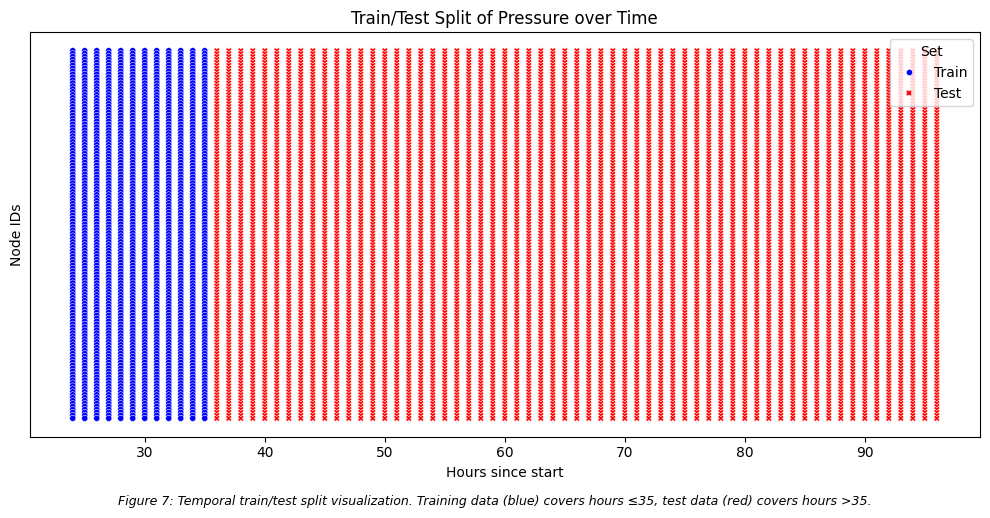

In [ ]:
# Visualization of the Train/Test Split by Node IDs
train_df = X_train.copy()
train_df['Set'] = 'Train'

test_df = X_test.copy()
test_df['Set'] = 'Test'

plot_df = pd.concat([train_df, test_df])

plt.figure(figsize=(10,5))
sns.scatterplot(
    data=plot_df,
    x='hours',
    y='Node',
    hue='Set',
    style='Set',
    palette={'Train': 'blue', 'Test': 'red'},
    s=20
)
plt.title('Train/Test Split of Pressure over Time')
plt.xlabel('Hours since start')
plt.ylabel('Node IDs')
plt.yticks([])
plt.figtext(0.5, -0.02, 'Figure 7: Temporal train/test split visualization. Training data (blue) covers hours ≤35, test data (red) covers hours >35.', 
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()

### XGBoost Regression Model

XGBoost is a distributed gradient boosting library (Tianqi et al., 2016) used for regression, classification and ranking for Python, C++, Java, R, Julia, Pearl and Scala. XGBoost implements gradient-boosted desicion trees that iteratively minimize a differential loss function of reweighted training data. (Friedmann et al., 2000). For this regression task, the xgboost python library is used for supervised learning. Tree complexity and regularization were selected empirically via tuning.

In [ ]:
# Definition of the regressor model
model = xgb.XGBRegressor(
    n_estimators=1000,        # number of boosting rounds
    eta=0.05,                # step size shrinkage
    colsample_bytree=0.8,    # % of features used per tree
)

# Model wrapper for multi-output regression
multi_model = MultiOutputRegressor(model)

# Model training
pipe = Pipeline([('prep', preprocess), ('model', multi_model)])

pipe.fit(X_train, Y_train);

### Neural Network Model

Multi-Layer Perceptrons (MLP) are a widely known way to implement neural networks and were introduced in the 1960s. A MLP is a feedforward neural network consisting of an input layer, one or more hidden layers, and an output layer. A layer of the MLP consists Each neuron computes a weighted sum of its inputs followed by a nonlinear activation function. Model parameters are learned by minimizing a loss function that measures the discrepancy between the network’s predictions and the target values, typically using gradient-based optimization.(Alameida, 1997). 

For this supervised learning task, the MLPRegressor from the sklearn library is used. Hyperparameters of the MLPRegressor are set empirically via tuning.


In [ ]:
from sklearn.neural_network import MLPRegressor

# Define MLP regressor and wrap for multi-output
mlp = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    alpha=0.0005,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    random_state=42,
)

multi_mlp = MultiOutputRegressor(mlp)

# Pipeline reusing the existing 'preprocess' transformer
nn_pipe = Pipeline([('prep', preprocess), ('model', multi_mlp)])

# Train
nn_pipe.fit(X_train, Y_train);

### Generalized Additive Model

GAMs employ linear predictors composed of smooth functions, potentially nonlinear functions of individual covariates to generate outputs. As Opposed to NN and XGBoost, which are considered "black-box" models, GAMs offer a transparent way of interpretability, since the whole model structure and the contribution of each covariate can be retreived and visualized. GAMs fall under the class of "glass-box" models (Hassija et al., 2024). Each feature is associated with its own learned smooth function and therefore offering insight of how individual inputs influence a GAMs generated outputs. Training involves optimizing each smooth function with a penalized likelihood.(Wood, 2025).

In this implementation, the PyGAM library is used to model the water network's pressure, demand, and head.(Servén et al., 2018)

In [ ]:
# Generalized Additive Model (GAM) for multi-output regression

# Define GAM regressor with smooth spline terms for each feature
gam = GAM(
    lam=0.6,
    n_splines=25,
    max_iter=100,
    tol=1e-3
)

multi_gam = MultiOutputRegressor(gam)

# Pipeline reusing the existing 'preprocess' transformer
gam_pipe = Pipeline([('prep', preprocess), ('model', multi_gam)])

# Train
gam_pipe.fit(X_train, Y_train);

### Explainable Boosting Machine

Explainable Boosting Machines (EBMs) are interpretable glass-box models that combine the accuracy of modern gradient boosting with the interpretability of generalized additive models. Developed by Microsoft Research as part of the InterpretML library, EBMs extend traditional GAMs by using gradient boosting and allowing pairwise feature interactions while maintaining full transparency (Nori et al., 2019; Lou et al., 2013). 

Unlike XGBoost, which builds complex trees that are difficult to interpret, EBMs build separate models for each feature and interaction term, making individual contributions directly observable. The algorithm uses round-robin boosting to ensure each feature receives equal representation in the model, preventing feature overshadowing common in traditional boosting methods. This architecture enables EBMs to achieve competitive predictive performance while providing explanations for both global model behavior and individual predictions.

For this supervised learning task, the ExplainableBoostingRegressor from the InterpretML library is used. Hyperparameters including interaction terms, bin sizes, and bagging parameters are set empirically via tuning.

In [ ]:
# Explainable Boosting Machine (EBM) for multi-output regression

# Define EBM regressor and wrap for multi-output
ebm = ExplainableBoostingRegressor(
    max_bins=256,
    max_interaction_bins=32,
    interactions=10,
    outer_bags=8,
    inner_bags=0,
    learning_rate=0.01,
    min_samples_leaf=2,
    max_leaves=3,
    random_state=42
)

multi_ebm = MultiOutputRegressor(ebm)

# Pipeline reusing the existing 'preprocess' transformer
ebm_pipe = Pipeline([('prep', preprocess), ('model', multi_ebm)])

# Train
ebm_pipe.fit(X_train, Y_train);

### Apply Trained Models to Make Prediction on Test Set

In [ ]:
# Predictions
y_pred = pipe.predict(X_test)
y_pred_df = pd.DataFrame(y_pred, columns=targets)

y_pred_nn = nn_pipe.predict(X_test)
y_pred_nn_df = pd.DataFrame(y_pred_nn, columns=targets, index=X_test.index)

y_pred_gam = gam_pipe.predict(X_test)
y_pred_gam_df = pd.DataFrame(y_pred_gam, columns=targets, index=X_test.index)

y_pred_ebm = ebm_pipe.predict(X_test)
y_pred_ebm_df = pd.DataFrame(y_pred_ebm, columns=targets, index=X_test.index)


### Model Evaluation


OVERALL MODEL EVALUATION RESULTS
         Model      RMSE        R²         MSE
       XGBoost  8.753686  0.954578   76.627014
Neural Network  5.618416  0.961253   31.566600
           GAM 38.150907 -0.614569 1455.491672
           EBM 15.735618  0.914203  247.609677

  Table 5: Overall model performance metrics (RMSE, R², MSE)
           across all target variables on the test set.



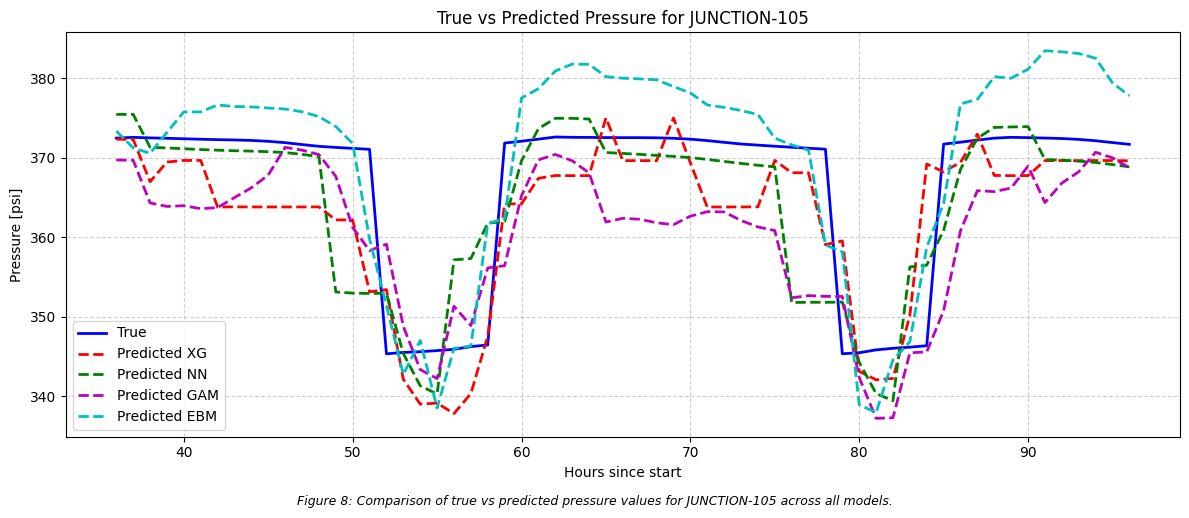


PRESSURE EVALUATION FOR JUNCTION-105
------------------------------------------------------------
         Model     RMSE       R²       MSE
       XGBoost 6.845445 0.594750 46.860111
Neural Network 7.495298 0.514156 56.179497
           GAM 8.719655 0.342466 76.032379
           EBM 6.787971 0.601527 46.076554
------------------------------------------------------------

  Table 6: Pressure prediction metrics for JUNCTION-105.
           Node-specific evaluation of model accuracy.



In [ ]:
# Evaluation by Prediction vs True Values for XGBoost
test_results = X_test.copy()
test_results['TruePressure'] = Y_test['Pressure [psi]'].values
test_results['PredictedPressure'] = y_pred_df['Pressure [psi]'].values
test_results['TrueDemand'] = Y_test['Demand'].values
test_results['PredictedDemand'] = y_pred_df['Demand'].values
test_results['TrueHead'] = Y_test['Head'].values
test_results['PredictedHead'] = y_pred_df['Head'].values


# Evaluation by Prediction vs True Values for NN
test_results_nn = X_test.copy()
test_results_nn['TruePressure'] = Y_test['Pressure [psi]'].values
test_results_nn['PredictedPressure'] = y_pred_nn_df['Pressure [psi]'].values
test_results_nn['TrueDemand'] = Y_test['Demand'].values
test_results_nn['PredictedDemand'] = y_pred_nn_df['Demand'].values
test_results_nn['TrueHead'] = Y_test['Head'].values
test_results_nn['PredictedHead'] = y_pred_nn_df['Head'].values

# Evaluation by Prediction vs True Values for GAM
test_results_gam = X_test.copy()
test_results_gam['TruePressure'] = Y_test['Pressure [psi]'].values
test_results_gam['PredictedPressure'] = y_pred_gam_df['Pressure [psi]'].values
test_results_gam['TrueDemand'] = Y_test['Demand'].values
test_results_gam['PredictedDemand'] = y_pred_gam_df['Demand'].values
test_results_gam['TrueHead'] = Y_test['Head'].values
test_results_gam['PredictedHead'] = y_pred_gam_df['Head'].values

# Evaluation by Prediction vs True Values for EBM
test_results_ebm = X_test.copy()
test_results_ebm['TruePressure'] = Y_test['Pressure [psi]'].values
test_results_ebm['PredictedPressure'] = y_pred_ebm_df['Pressure [psi]'].values
test_results_ebm['TrueDemand'] = Y_test['Demand'].values
test_results_ebm['PredictedDemand'] = y_pred_ebm_df['Demand'].values
test_results_ebm['TrueHead'] = Y_test['Head'].values
test_results_ebm['PredictedHead'] = y_pred_ebm_df['Head'].values

# Overall Evaluation Metrics for all models
# XGBoost
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)

# NN
mse_nn = mean_squared_error(Y_test, y_pred_nn)
rmse_nn = np.sqrt(mse_nn)
r2_nn = r2_score(Y_test, y_pred_nn)

# GAM
mse_gam = mean_squared_error(Y_test, y_pred_gam)
rmse_gam = np.sqrt(mse_gam)
r2_gam = r2_score(Y_test, y_pred_gam)

# EBM
mse_ebm = mean_squared_error(Y_test, y_pred_ebm)
rmse_ebm = np.sqrt(mse_ebm)
r2_ebm = r2_score(Y_test, y_pred_ebm)

# Create a comprehensive evaluation table
evaluation_results = pd.DataFrame({
    'Model': ['XGBoost', 'Neural Network', 'GAM', 'EBM'],
    'RMSE': [rmse, rmse_nn, rmse_gam, rmse_ebm],
    'R²': [r2, r2_nn, r2_gam, r2_ebm],
    'MSE': [mse, mse_nn, mse_gam, mse_ebm]
})

print("\n" + "="*60)
print("OVERALL MODEL EVALUATION RESULTS")
print("="*60)
print(evaluation_results.to_string(index=False))
print("="*60)
print("\n  Table 5: Overall model performance metrics (RMSE, R², MSE)")
print("           across all target variables on the test set.\n")

# Evaluation & Visualization for a specific Node
node_name = 'JUNCTION-105'   
node_df = test_results[test_results['Node'] == node_name].copy()
node_df_nn = test_results_nn[test_results_nn['Node'] == node_name].copy()
node_df_gam = test_results_gam[test_results_gam['Node'] == node_name].copy()
node_df_ebm = test_results_ebm[test_results_ebm['Node'] == node_name].copy()

# Pressure Plot
plt.figure(figsize=(12,5))
plt.plot(node_df['hours'], node_df['TruePressure'], 'b-', label='True', linewidth=2)
plt.plot(node_df['hours'], node_df['PredictedPressure'], 'r--', label='Predicted XG', linewidth=2)
plt.plot(node_df_nn['hours'], node_df_nn['PredictedPressure'], 'g--', label='Predicted NN', linewidth=2)
plt.plot(node_df_gam['hours'], node_df_gam['PredictedPressure'], 'm--', label='Predicted GAM', linewidth=2)
plt.plot(node_df_ebm['hours'], node_df_ebm['PredictedPressure'], 'c--', label='Predicted EBM', linewidth=2)
plt.xlabel('Hours since start')
plt.ylabel('Pressure [psi]')
plt.title(f'True vs Predicted Pressure for {node_name}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.figtext(0.5, -0.02, f'Figure 8: Comparison of true vs predicted pressure values for {node_name} across all models.', 
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()

# Pressure Evaluation Metrics for the specific Node
node_press_mse = mean_squared_error(node_df['TruePressure'], node_df['PredictedPressure'])
node_press_rmse = np.sqrt(node_press_mse)
node_press_r2 = r2_score(node_df['TruePressure'], node_df['PredictedPressure'])

node_press_mse_nn = mean_squared_error(node_df_nn['TruePressure'], node_df_nn['PredictedPressure'])
node_press_rmse_nn = np.sqrt(node_press_mse_nn)
node_press_r2_nn = r2_score(node_df_nn['TruePressure'], node_df_nn['PredictedPressure'])

node_press_mse_gam = mean_squared_error(node_df_gam['TruePressure'], node_df_gam['PredictedPressure'])
node_press_rmse_gam = np.sqrt(node_press_mse_gam)
node_press_r2_gam = r2_score(node_df_gam['TruePressure'], node_df_gam['PredictedPressure'])

node_press_mse_ebm = mean_squared_error(node_df_ebm['TruePressure'], node_df_ebm['PredictedPressure'])
node_press_rmse_ebm = np.sqrt(node_press_mse_ebm)
node_press_r2_ebm = r2_score(node_df_ebm['TruePressure'], node_df_ebm['PredictedPressure'])

# Pressure evaluation table
pressure_eval = pd.DataFrame({
    'Model': ['XGBoost', 'Neural Network', 'GAM', 'EBM'],
    'RMSE': [node_press_rmse, node_press_rmse_nn, node_press_rmse_gam, node_press_rmse_ebm],
    'R²': [node_press_r2, node_press_r2_nn, node_press_r2_gam, node_press_r2_ebm],
    'MSE': [node_press_mse, node_press_mse_nn, node_press_mse_gam, node_press_mse_ebm]
})

print(f"\nPRESSURE EVALUATION FOR {node_name}")
print("-"*60)
print(pressure_eval.to_string(index=False))
print("-"*60)
print(f"\n  Table 6: Pressure prediction metrics for {node_name}.")
print("           Node-specific evaluation of model accuracy.\n")

### Evaluation Remarks



From the overall evaluation metrics, the Neural Network clearly emerges as the top performer, followed by XGBoost, followed by EBM and GAM showing weaker performance. The R² scores across all the three top perfomers,  remain relatively high (typically > 0.90).

The Neural Network demonstrates the strongest prediction capabilites with consistently low error metrics across all three target variables (Pressure, Demand, and Head). XGBoost performs as a second-place contender, showing predictions with only marginally higher errors than the Neural Network.

The EMB, despite its interpretability advantages, shows weaker performance compared to both Neural Network and XGBoost. All evaluation metrics (RMSE, R², MSE) consistently indicate that EBM struggles to achieve the same level of accuracy as the leading models. This performance gap suggests that EBM's generalized additive structure with pairwise interactions may be insufficient to fully capture the interactions present in hydraulic systems.

The GAM shows the worst performance compared to the three top performers. GAMs provide excellent interpretability through smooth functions, but their inherent assumption of additive separability limits their ability to capture the complex interactions present in water distribution systems. The performance gap indicates that hydraulic variables interact in ways that cannot be adequately represented as sums of univariate smooth functions.

## Explainability

Understanding why models make certain predictions is crucial for operational decision-making in water distribution systems. While Neural Networks and XGBoost offer superior predictive performance, their complexity makes interpretation challenging. This section explores post-hoc explainability techniques to provide insights into model behavior and feature contributions.

To study explainability, two methods are used. SHAP uses game-theoretic Shapley values to assign each feature an additive contribution to a prediction, revealing how inputs push an output away from the baseline. Permutation importance measures feature influence by observing the drop in performance when a feature’s values are randomly shuffled, capturing effects that arise through both main contributions and interactions. Together, these methods highlight which hydraulic parameters (elevation, demand multiplier, lag features, etc.) drive predictions and let operators verify that the models are learning relationships that are physically meaningful.

### SHAP Values Analysis

SHAP values provide a unified measure of feature importance based on cooperative game theory. For each prediction, SHAP values show how much each feature contributed to moving the prediction away from the average baseline prediction. Positive SHAP values push predictions higher, while negative values push them lower.(Lundberg & Lee, 2017)

The analysis of SHAP values reveals distinct patterns in how each model leverages features for pressure prediction. A common trend across all models is the significant contribution of lag values, which are critical for enhancing prediction accuracy. However, the prioritization of these lags varies: XGBoost, EBM, and GAM consistently rank pressure lags as the most influential features, whereas the NN assigns greater importance to head lags.

Notably, while most models (excluding XGBoost) identify elevation as an important feature, the Neural Network effectively integrates the importance of elevation with head lags. Given the direct hydraulic relationship between these variables and pressure, this synergy likely underpins the NN's superior predictive performance. In contrast, XGBoost appears to function as a physically agnostic model, deriving its predictions almost exclusively from pressure lags without assigning significant weight to physical constraints like elevation. This reliance risks reducing the model to a statistical "black box," potentially limiting its generalizability if the network's physical configuration, such as node elevations, were to change.

Furthermore, all ensemble models exhibit some reliance on specific junction identifiers, suggesting they have captured certain spatial relationships within the network. The Explainable Boosting Machine (EBM) places the highest importance on individual junctions, indicating a more developed spatial understanding compared to other models. This characteristic may stem from EBM's architecture, which forces the boosting of each feature, whereas XGBoost selectively boosts only the most effective trees, making it prone to feature overshadowing.

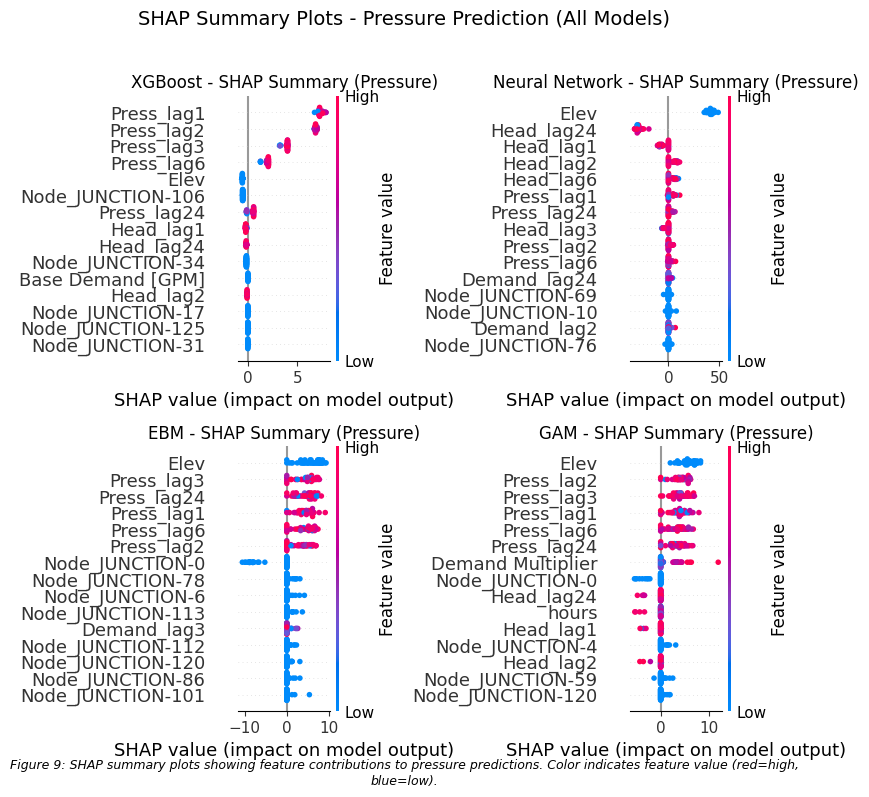

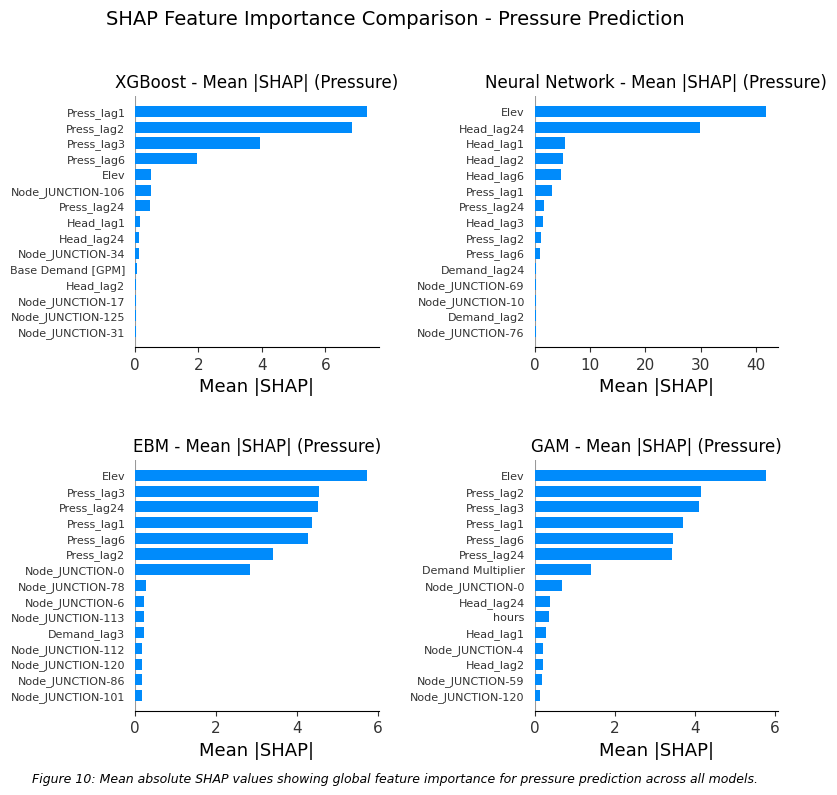

In [ ]:
import shap
import warnings

# SHAP Analysis for All Models (Pressure Prediction)

# Get preprocessed data for SHAP analysis
X_train_processed = pipe.named_steps['prep'].transform(X_train)
X_test_processed = pipe.named_steps['prep'].transform(X_test)

# Get feature names after preprocessing
onehot_features = pipe.named_steps['prep'].named_transformers_['OneHot'].get_feature_names_out(['Node']).tolist()
numeric_features = [col for col in X_train.columns if col != 'Node']
all_feature_names = onehot_features + numeric_features

# Extract models for each target
pressure_model = pipe.named_steps['model'].estimators_[0]
demand_model = pipe.named_steps['model'].estimators_[1]
head_model = pipe.named_steps['model'].estimators_[2]

# Sample sizes for efficiency (reduced for faster computation)
n_background = 50  # Background samples for KernelExplainer
n_test_samples = 50  # Test samples to explain
n_shap_samples = 100  # Number of perturbation samples per explanation

# Create background sample for KernelExplainer-based models
background_sample = shap.sample(X_train_processed, n_background)
background_df = pd.DataFrame(background_sample, columns=all_feature_names)

# 1. XGBoost SHAP (TreeExplainer)
explainer_pressure = shap.TreeExplainer(pressure_model)
shap_values_pressure = explainer_pressure.shap_values(X_test_processed[:500])

# 2. Neural Network SHAP (KernelExplainer)
X_test_nn_processed = nn_pipe.named_steps['prep'].transform(X_test)
nn_pressure_model = nn_pipe.named_steps['model'].estimators_[0]
explainer_nn_pressure = shap.KernelExplainer(nn_pressure_model.predict, background_sample)
shap_values_nn_pressure = explainer_nn_pressure.shap_values(X_test_nn_processed[:n_test_samples], nsamples=n_shap_samples, silent=True)

# 3. EBM SHAP (KernelExplainer - using numpy arrays to avoid feature name warnings)
X_test_ebm_processed = ebm_pipe.named_steps['prep'].transform(X_test)
ebm_pressure_model = ebm_pipe.named_steps['model'].estimators_[0]

# Suppress the InterpretML feature name warning for EBM
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='.*does not contain all feature names.*')
    
    def ebm_predict_wrapper(X_array):
        """Wrapper to handle EBM prediction with numpy arrays."""
        return ebm_pressure_model.predict(X_array)

    explainer_ebm_pressure = shap.KernelExplainer(ebm_predict_wrapper, background_sample)
    shap_values_ebm_pressure = explainer_ebm_pressure.shap_values(X_test_ebm_processed[:n_test_samples], nsamples=n_shap_samples, silent=True)

# 4. GAM SHAP (KernelExplainer - optimized with reduced samples)
X_test_gam_processed = gam_pipe.named_steps['prep'].transform(X_test)
gam_pressure_model = gam_pipe.named_steps['model'].estimators_[0]
explainer_gam_pressure = shap.KernelExplainer(gam_pressure_model.predict, background_sample)
shap_values_gam_pressure = explainer_gam_pressure.shap_values(X_test_gam_processed[:n_test_samples], nsamples=n_shap_samples, silent=True)

# SHAP Summary Plots - Individual Models
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# XGBoost Summary Plot
plt.sca(axes[0, 0])
shap.summary_plot(shap_values_pressure[:n_test_samples], X_test_processed[:n_test_samples], 
                  feature_names=all_feature_names, show=False, max_display=15)
axes[0, 0].set_title('XGBoost - SHAP Summary (Pressure)', fontsize=12)

# Neural Network Summary Plot
plt.sca(axes[0, 1])
shap.summary_plot(shap_values_nn_pressure, X_test_nn_processed[:n_test_samples], 
                  feature_names=all_feature_names, show=False, max_display=15)
axes[0, 1].set_title('Neural Network - SHAP Summary (Pressure)', fontsize=12)

# EBM Summary Plot
plt.sca(axes[1, 0])
shap.summary_plot(shap_values_ebm_pressure, X_test_ebm_processed[:n_test_samples], 
                  feature_names=all_feature_names, show=False, max_display=15)
axes[1, 0].set_title('EBM - SHAP Summary (Pressure)', fontsize=12)

# GAM Summary Plot
plt.sca(axes[1, 1])
shap.summary_plot(shap_values_gam_pressure, X_test_gam_processed[:n_test_samples], 
                  feature_names=all_feature_names, show=False, max_display=15)
axes[1, 1].set_title('GAM - SHAP Summary (Pressure)', fontsize=12)

plt.suptitle('SHAP Summary Plots - Pressure Prediction (All Models)', fontsize=14, y=1.02)
plt.figtext(0.5, -0.01, 'Figure 9: SHAP summary plots showing feature contributions to pressure predictions. Color indicates feature value (red=high, blue=low).', 
            ha='center', fontsize=9, style='italic', wrap=True)
plt.tight_layout()
plt.show()

# SHAP Bar Plots - Mean Absolute SHAP Values Comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

plt.sca(axes[0, 0])
shap.summary_plot(shap_values_pressure[:n_test_samples], X_test_processed[:n_test_samples], 
                  feature_names=all_feature_names, plot_type="bar", show=False, max_display=15)
axes[0, 0].set_title('XGBoost - Mean |SHAP| (Pressure)', fontsize=12)
axes[0, 0].tick_params(axis='y', labelsize=8)
axes[0, 0].set_xlabel('Mean |SHAP|')

plt.sca(axes[0, 1])
shap.summary_plot(shap_values_nn_pressure, X_test_nn_processed[:n_test_samples], 
                  feature_names=all_feature_names, plot_type="bar", show=False, max_display=15)
axes[0, 1].set_title('Neural Network - Mean |SHAP| (Pressure)', fontsize=12)
axes[0, 1].tick_params(axis='y', labelsize=8)
axes[0, 1].set_xlabel('Mean |SHAP|')

plt.sca(axes[1, 0])
shap.summary_plot(shap_values_ebm_pressure, X_test_ebm_processed[:n_test_samples], 
                  feature_names=all_feature_names, plot_type="bar", show=False, max_display=15)
axes[1, 0].set_title('EBM - Mean |SHAP| (Pressure)', fontsize=12)
axes[1, 0].tick_params(axis='y', labelsize=8)
axes[1, 0].set_xlabel('Mean |SHAP|')

plt.sca(axes[1, 1])
shap.summary_plot(shap_values_gam_pressure, X_test_gam_processed[:n_test_samples], 
                  feature_names=all_feature_names, plot_type="bar", show=False, max_display=15)
axes[1, 1].set_title('GAM - Mean |SHAP| (Pressure)', fontsize=12)
axes[1, 1].tick_params(axis='y', labelsize=8)
axes[1, 1].set_xlabel('Mean |SHAP|')

plt.suptitle('SHAP Feature Importance Comparison - Pressure Prediction', fontsize=14, y=1.02)
plt.figtext(0.5, -0.01, 'Figure 10: Mean absolute SHAP values showing global feature importance for pressure prediction across all models.', 
            ha='center', fontsize=9, style='italic', wrap=True)
plt.tight_layout(h_pad=3, w_pad=2)
plt.show()

### Permutation Importance

Permutation importance measures the decrease in model performance when a single feature's values are randomly shuffled. Unlike built-in feature importance, this method captures the actual impact on predictions and can detect features that are important due to interactions with other features.(Altmann et al., 2010)

Permutation importance analysis further shows the models' dependencies and their alignment with physical principles. The Neural Network exhibits the most substantial maximum decrease in $R^2$ score (~14) when individual features are shuffled, confirming its strong reliance on both elevation and cyclical (24-hour) head lags. This dependence suggests that the NN has successfully internalized the fundamental hydraulic relationship between pressure, elevation, and head, effectively assuming daily cyclical pressure patterns.

Conversely, the XGBoost model shows a much smaller reduction in performance when features are permuted, though it remains heavily dependent on pressure lag features. This reinforces the observation that XGBoost operates primarily on historical performance metrics rather than an underlying physical understanding of hydraulics. In critical infrastructure contexts like water networks, this behavior poses a risk; sensor failures could lead to rapid model collapse. The Neural Network’s reliance on physical parameters like elevation and 24-hour head trends offers a more robust buffer, potentially allowing more time for failure analysis before predictions degrade significantly.

GAM demonstrates a primary reliance on physical elevation, aligning with the hydrostatic pressure formula ($P = \rho g h$). However, its limited emphasis on head lags (compared to elevation) suggests a weaker grasp of the comprehensive hydraulic dynamics relative to the NN.

Finally, the EBM assigns high permutation importance to specific junction identifiers, effectively utilizing them as "pressure benchmarks," even if they lack direct physical prominence. Its lower reliance on head lags compared to the NN implies that EBM's predictive strategy is analogous to XGBoost's, combining past pressure data with these spatial benchmarks rather than fully exploiting hydraulic principles.

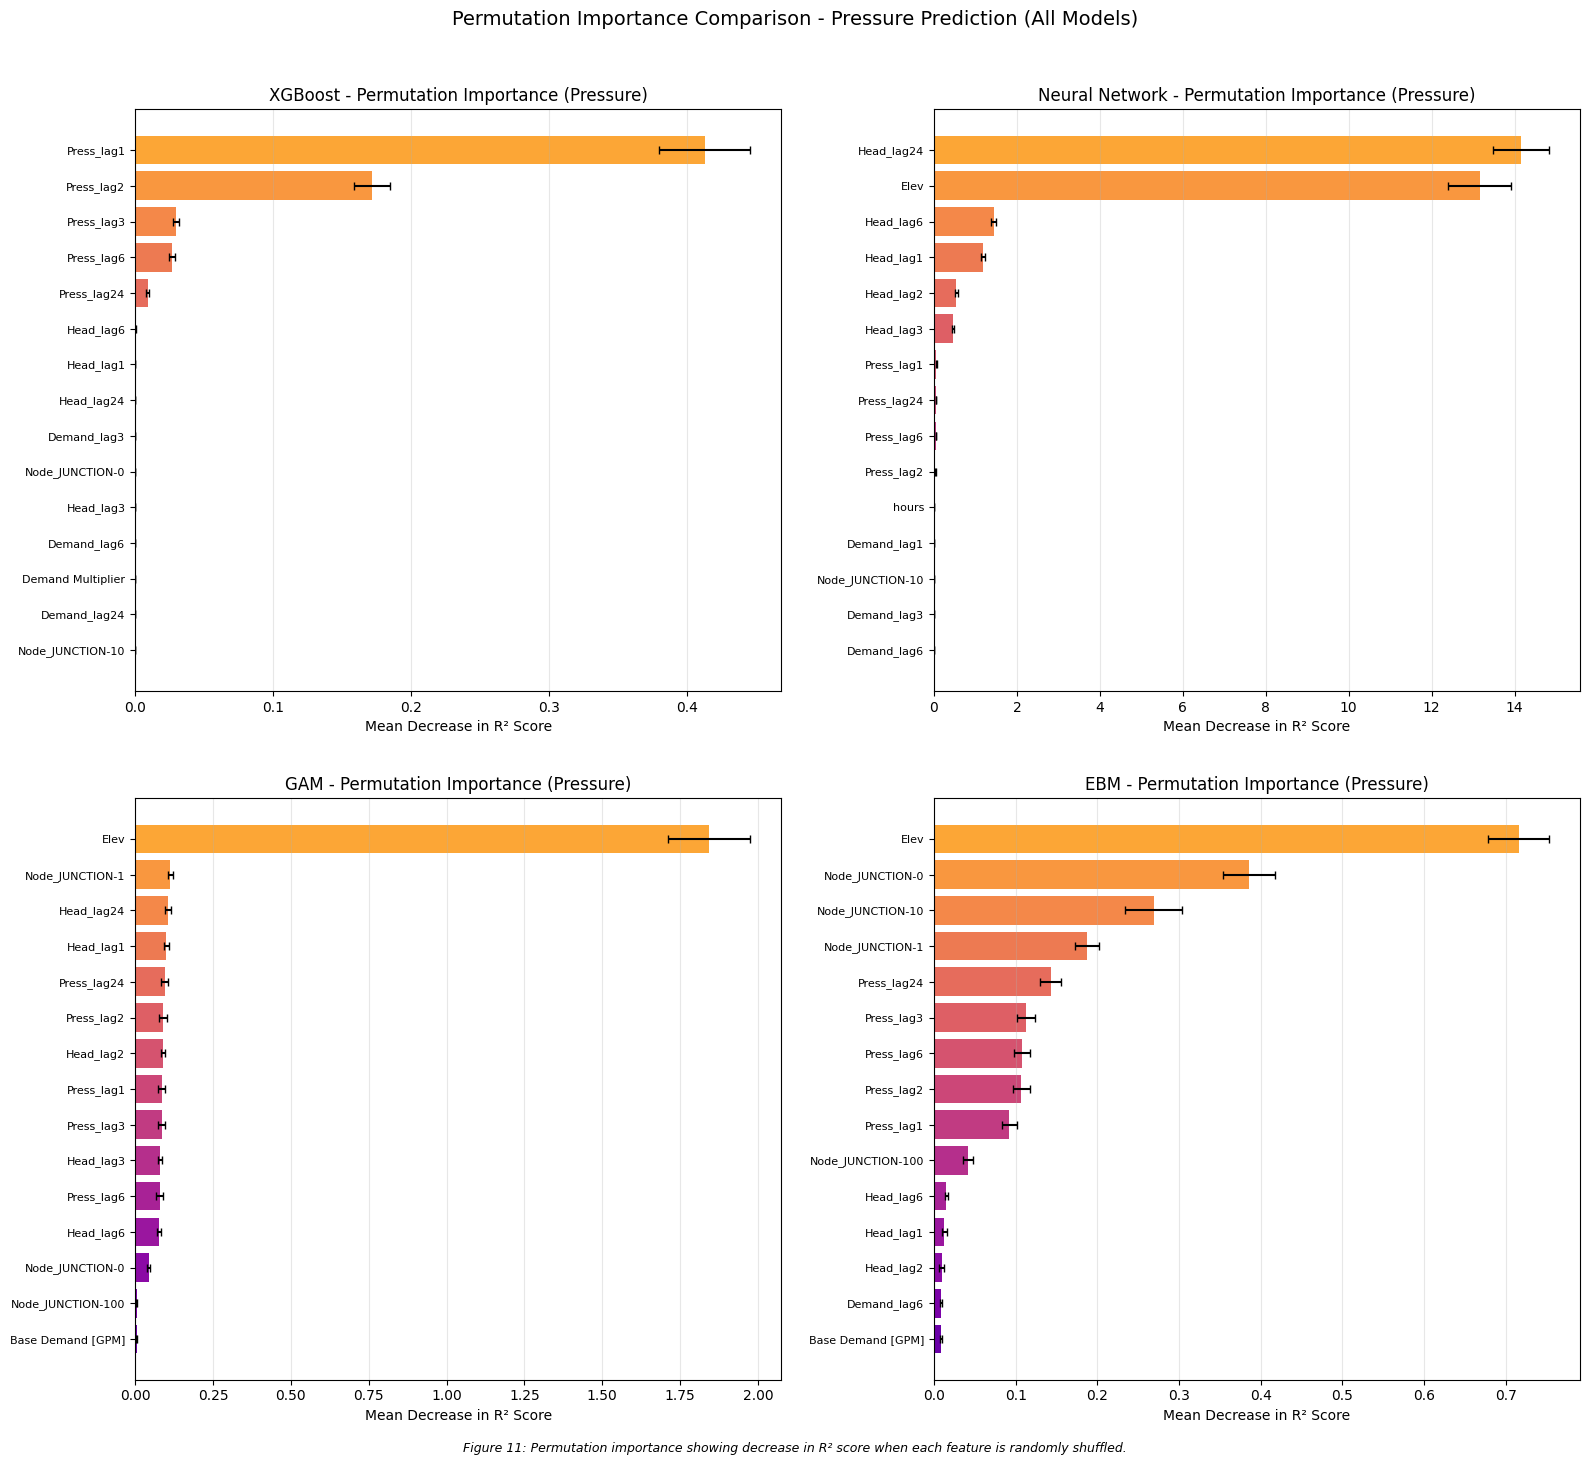

In [ ]:
from sklearn.inspection import permutation_importance

# Prepare test subsets
n_perm_samples = 200  # Samples for permutation importance
X_test_subset = X_test_processed[:n_perm_samples]
Y_test_pressure = Y_test.iloc[:n_perm_samples]['Pressure [psi]']

# Extract pressure models from each pipeline
xgb_pressure_model = pipe.named_steps['model'].estimators_[0]
nn_pressure_model = nn_pipe.named_steps['model'].estimators_[0]
gam_pressure_model = gam_pipe.named_steps['model'].estimators_[0]
ebm_pressure_model = ebm_pipe.named_steps['model'].estimators_[0]

# Preprocessed test data for each model
X_test_nn_subset = nn_pipe.named_steps['prep'].transform(X_test)[:n_perm_samples]
X_test_gam_subset = gam_pipe.named_steps['prep'].transform(X_test)[:n_perm_samples]
X_test_ebm_subset = ebm_pipe.named_steps['prep'].transform(X_test)[:n_perm_samples]

# Model configurations (use numpy arrays for all models to avoid feature name mismatches)
model_configs = [
    ('XGBoost', xgb_pressure_model, X_test_subset),
    ('Neural Network', nn_pressure_model, X_test_nn_subset),
    ('GAM', gam_pressure_model, X_test_gam_subset),
    ('EBM', ebm_pressure_model, X_test_ebm_subset),  # Pass numpy array directly
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (model_name, model, X_data) in enumerate(model_configs):    
    # Compute permutation importance
    perm_importance = permutation_importance(
        model, X_data, Y_test_pressure, 
        n_repeats=10, random_state=42, n_jobs=-1
    )
    
    # Create DataFrame for plotting
    perm_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': perm_importance.importances_mean,
        'Std': perm_importance.importances_std
    }).sort_values('Importance', ascending=True).tail(15)  # Top 15 features
    
    colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(perm_df)))
    axes[idx].barh(perm_df['Feature'], perm_df['Importance'], xerr=perm_df['Std'], 
                   color=colors, capsize=3)
    axes[idx].set_xlabel('Mean Decrease in R² Score')
    axes[idx].set_title(f'{model_name} - Permutation Importance (Pressure)', fontsize=12)
    axes[idx].tick_params(axis='y', labelsize=8)
    axes[idx].grid(axis='x', alpha=0.3)

plt.suptitle('Permutation Importance Comparison - Pressure Prediction (All Models)', fontsize=14, y=1.02)
plt.figtext(0.5, -0.01, 'Figure 11: Permutation importance showing decrease in R² score when each feature is randomly shuffled.', 
            ha='center', fontsize=9, style='italic', wrap=True)
plt.tight_layout(h_pad=3, w_pad=2)
plt.show()

### Conclusion  

In conclusion, while XGBoost, the Neural Network (NN), and the Explainable Boosting Machine (EBM) all demonstrate strong capabilities in predicting future pressure values, the Neural Network emerges as the superior model. It outperforms the ensemble not only in statistical metrics but also in its adherence to physical realism. By consistently prioritizing features that share a proportional and physically explainable relationship with pressure, the Neural Network offers a robust and reliable tool for water network analysis. 

# References

Almeida, Luis B. "Multilayer perceptrons." Handbook of neural computation. CRC Press, 2020. C1-2.

Altmann A., Toloşi L., Sander O., Lengauer T. (2010). Permutation importance: a corrected feature importance measure, Bioinformatics, Volume 26, Issue 10, Pages 1340–1347, https://doi.org/10.1093/bioinformatics/btq134

Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. In Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining, pp. 785-794. https://doi.org/10.1145/2939672.2939785

Friedman, J., Hastie, T., Tibshirani, R. (2000). Additive logistic Regression: A statistical view of boosting. The Annals of Statistics, Vol. 28, No. 2, 337-407, 

Hassija, V., Chamola, V., Mahapatra, A. et al. Interpreting Black-Box Models: A Review on Explainable Artificial Intelligence. Cogn Comput 16, 45–74 (2024). https://doi.org/10.1007/s12559-023-10179-8

Lou, Y., Caruana, R., & Gehrke, J. (2012). Intelligible Models for Classification and Regression. In Proceedings of the 18th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (KDD '12), pp. 150-158. https://doi.org/10.1145/2339530.2339556 

Lundberg, S. M., & Lee, S. I. (2017). A unified approach to interpreting model predictions. Advances in neural information processing systems, 30. https://arxiv.org/abs/1705.07874

Nori, H., Jenkins, S., Koch, P., & Caruana, R. (2019). InterpretML: A Unified Framework for Machine Learning Interpretability. arXiv preprint arXiv:1909.09223. https://arxiv.org/abs/1909.09223

Ostfeld, A. (2021). 02 Water Sensor Network 1. Battle of the Water Network Models. 3. https://uknowledge.uky.edu/wdst_models/3

Rossman, L. A. (2000). EPANET 2: Users manual. U.S. Environmental Protection Agency.

Simon N. Wood. 2025. Generalized Additive Models. Annual Review Statistics and Its Application. 12:497-526. https://doi.org/10.1146/annurev-statistics-112723-034249

Servén D., Brummitt C. (2018). pyGAM: Generalized Additive Models in Python. Zenodo. DOI: 10.5281/zenodo.1208723